In [1]:
medical_charges_url = 'https://raw.githubusercontent.com/JovianML/opendatasets/master/data/medical-charges.csv'

In [2]:
from urllib.request import urlretrieve
urlretrieve(medical_charges_url, 'medical.csv')

('medical.csv', <http.client.HTTPMessage at 0x7f9f189a5d90>)

In [57]:
import pandas as pd

medical_df = pd.read_csv('medical.csv')

In [2]:
import plotly.express as px
import matplotlib 
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [3]:
sns.set_style('darkgrid')
matplotlib.rcParams['font.size'] = 14
matplotlib.rcParams['figure.figsize'] = (10, 6)
matplotlib.rcParams['figure.facecolor'] = '#00000000'

In [4]:
medical_df.age.describe()

count    1338.000000
mean       39.207025
std        14.049960
min        18.000000
25%        27.000000
50%        39.000000
75%        51.000000
max        64.000000
Name: age, dtype: float64

In [5]:
fig= px.histogram(medical_df,x='age',nbins=47,marginal='box',title='Distribution of Age')
fig.update_layout(bargap=0.1)
fig.show()

In [6]:
fig=px.histogram(medical_df,x='bmi',marginal='box',color_discrete_sequence=['red'],title='Distribution of BMI')
fig.update_layout(bargap=0.1)
fig.show()

In [7]:
fig=px.histogram(medical_df,x='charges',marginal='box',color='smoker',color_discrete_sequence=['green','grey'],title='Distribution of Charges')
fig.update_layout(bargap=0.1)
fig.show()

In [8]:
medical_df.smoker.value_counts()

smoker
no     1064
yes     274
Name: count, dtype: int64

In [9]:
px.histogram(medical_df,x='smoker',color='sex',title='Distribution of Smokers and Non-Smokers',)

In [10]:
fig=px.scatter(medical_df,x='age',y='charges',color='smoker',opacity=0.8,hover_data=['sex'],title='Age vs Charges')
fig.update_traces(marker_size=5)
fig.show()

In [11]:
fig=px.scatter(medical_df,x='bmi',y='charges',color='smoker',opacity=0.8,hover_data=['sex'],title='BMI vs Charges')
fig.update_traces(marker_size=5)
fig.show()

In [12]:
px.violin(medical_df,x='children',y='charges',title='Children vs Charges')

In [13]:
print(medical_df.charges.corr(medical_df.age))
print(medical_df.charges.corr(medical_df.bmi))

0.2990081933306476
0.19834096883362895


In [66]:
smoker_values={'no':0,'yes':1}
sex_values={'male':0,'female':0}
medical_df['smoker_codes']=medical_df.smoker.map(smoker_values)
medical_df['sex_codes']=medical_df.sex.map(sex_values)
# print(medical_df.charges.corr(medical_df.smoker))

In [15]:
medical_df.drop('region',axis=1, inplace=True)

In [16]:
medical_df.corr()

,age,sex,bmi,children,smoker,charges
age,1.000000,0.020856,0.109272,0.042469,-0.025019,0.299008
sex,0.020856,1.000000,-0.046371,-0.017163,-0.076185,-0.057292
bmi,0.109272,-0.046371,1.000000,0.012759,0.003750,0.198341
children,0.042469,-0.017163,0.012759,1.000000,0.007673,0.067998
smoker,-0.025019,-0.076185,0.003750,0.007673,1.000000,0.787251
charges,0.299008,-0.057292,0.198341,0.067998,0.787251,1.000000


Text(0.5, 1.0, 'correlation  matrix')

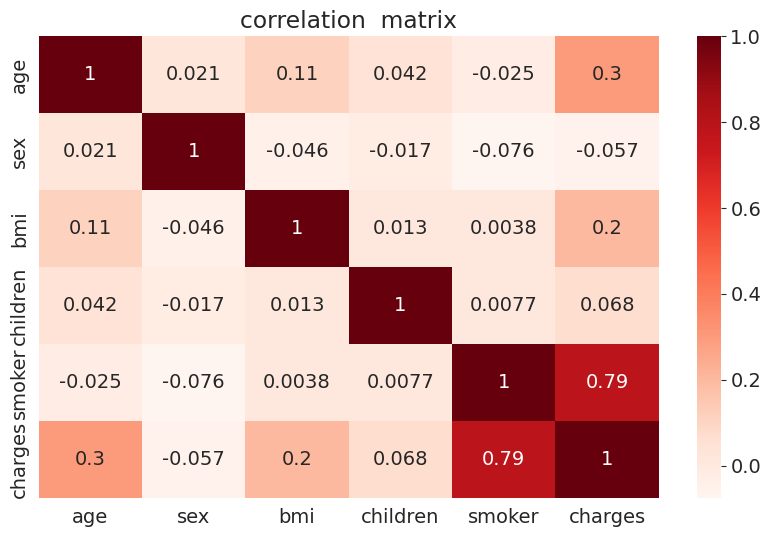

In [17]:
sns.heatmap(medical_df.corr(),cmap='Reds',annot=True)
plt.title('correlation  matrix')

<Axes: title={'center': 'Age vs chaarges for non-smoker'}, xlabel='age', ylabel='charges'>

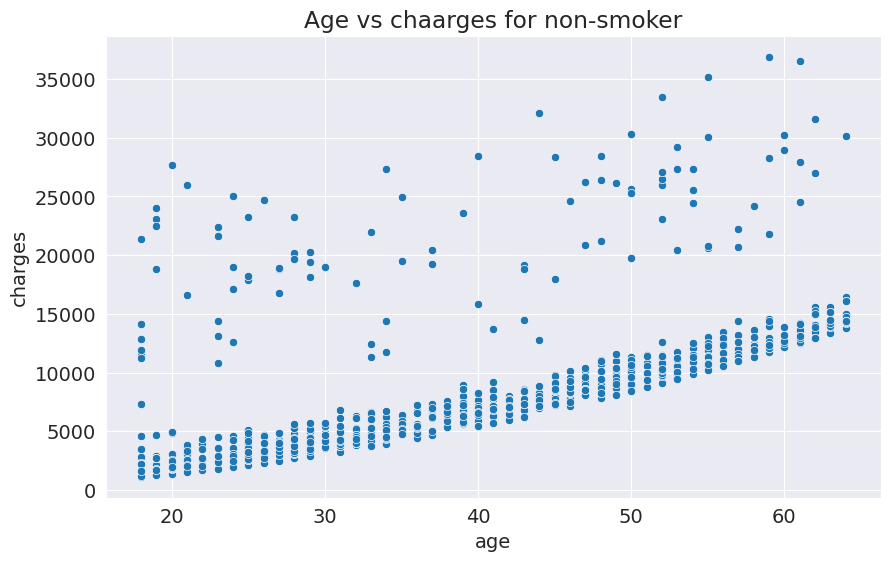

In [18]:
non_smoker_df=medical_df[medical_df.smoker == 0]
plt.title('Age vs chaarges for non-smoker')
sns.scatterplot(x='age',y='charges',data=non_smoker_df)

In [19]:
def estimate_charges(age,w=50,b=100):
    
    return w*age + b

In [20]:
ages=non_smoker_df.age
ages

1       18
2       28
3       33
4       32
5       31
        ..
1332    52
1333    50
1334    18
1335    18
1336    21
Name: age, Length: 1064, dtype: int64

In [21]:
estimate_charges_=estimate_charges(ages)
estimate_charges_

1       1000
2       1500
3       1750
4       1700
5       1650
        ... 
1332    2700
1333    2600
1334    1000
1335    1000
1336    1150
Name: age, Length: 1064, dtype: int64

In [22]:
def try_parameters(w,b):
    ages=non_smoker_df.age
    estimate_charges_=estimate_charges(ages,w,b)
    plt.plot(ages,estimate_charges_,'r',)
    plt.scatter(ages,non_smoker_df.charges)
    plt.xlabel('age')
    plt.ylabel('charges')
    plt.legend(['estimated charges','actual charges'])

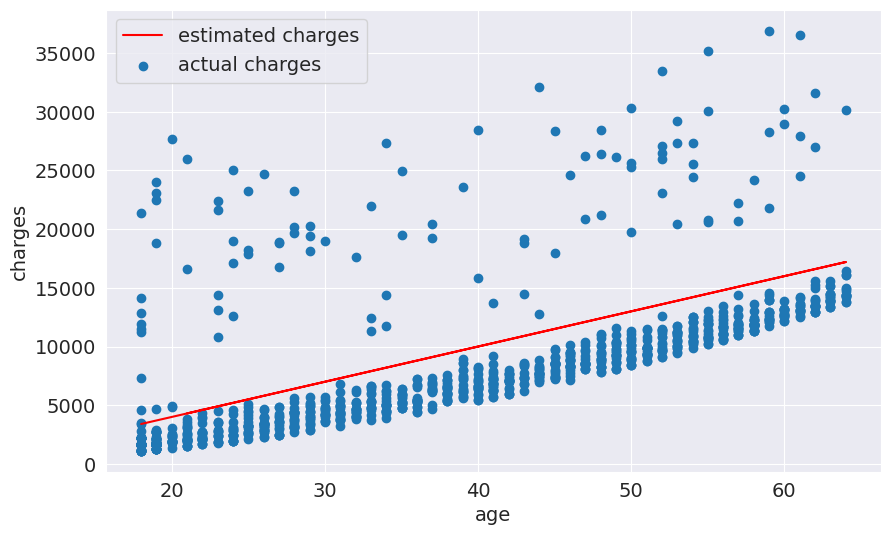

In [23]:
try_parameters(300,-2000)

In [24]:
import numpy as np
def rmse(targets,predictions):
    return np.sqrt(np.mean(np.square(targets-predictions)))

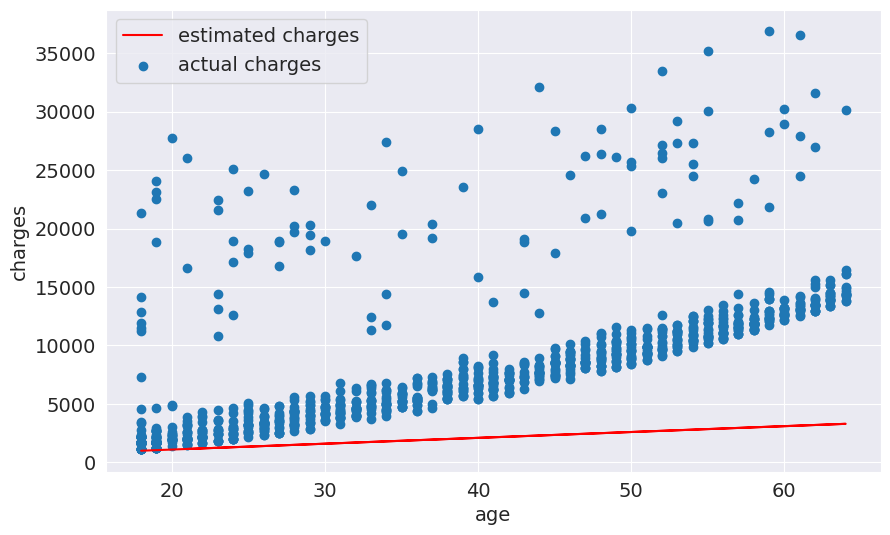

In [25]:
w=50
b=100
try_parameters(w,b)

In [26]:
def try_parameters(w,b):
    ages=non_smoker_df.age
    estimate_charges_=estimate_charges(ages,w,b)
    plt.plot(ages,estimate_charges_,'r',)
    plt.scatter(ages,non_smoker_df.charges)
    plt.xlabel('age')
    plt.ylabel('charges')
    plt.legend(['estimated charges','actual charges'])
    loss=rmse(non_smoker_df.charges,estimate_charges_)
    print('Rmse loss: ',loss)

In [27]:
targets=non_smoker_df.charges
predictions=estimate_charges(non_smoker_df.age,w,b)
print(rmse(targets,predictions))

8461.949562575493


Rmse loss:  4767.416184562645


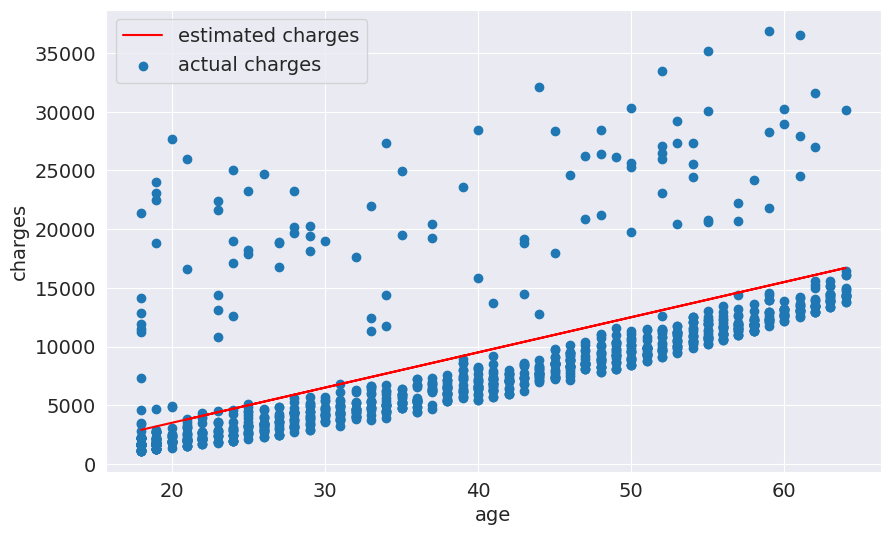

In [28]:
try_parameters(300,-2500)

In [41]:
from sklearn.linear_model import LinearRegression,SGDRegressor
model=LinearRegression()
model_=SGDRegressor()

In [30]:
help(model.fit)

Help on method fit in module sklearn.linear_model._base:

fit(X, y, sample_weight=None) method of sklearn.linear_model._base.LinearRegression instance
    Fit linear model.
    
    Parameters
    ----------
    X : {array-like, sparse matrix} of shape (n_samples, n_features)
        Training data.
    
    y : array-like of shape (n_samples,) or (n_samples, n_targets)
        Target values. Will be cast to X's dtype if necessary.
    
    sample_weight : array-like of shape (n_samples,), default=None
        Individual weights for each sample.
    
        .. versionadded:: 0.17
           parameter *sample_weight* support to LinearRegression.
    
    Returns
    -------
    self : object
        Fitted Estimator.



In [37]:
inputs=non_smoker_df[['age']]
targets=non_smoker_df.charges
print('input.shape :',inputs.shape)
print('target.shape :',targets.shape)

input.shape : (1064, 1)
target.shape : (1064,)


In [43]:
model.fit(inputs,targets)
model_.fit(inputs,targets)

SGDRegressor()

In [44]:
print(model.predict(np.array([[23],[37],[61]])))
print(model_.predict(np.array([[23],[37],[61]])))

[ 4055.30443855  7796.78921819 14210.76312614]
[ 2008.97845485  6675.50416029 14675.26251247]


/home/somanathan/Desktop/qgreeks-be-platform-apis/.venv/lib/python3.11/site-packages/sklearn/base.py:493: UserWarning:

X does not have valid feature names, but LinearRegression was fitted with feature names

/home/somanathan/Desktop/qgreeks-be-platform-apis/.venv/lib/python3.11/site-packages/sklearn/base.py:493: UserWarning:

X does not have valid feature names, but SGDRegressor was fitted with feature names



In [45]:
predictions=model.predict(inputs)
print(predictions)
predictions_=model_.predict(inputs)
print(predictions_)

[2719.0598744  5391.54900271 6727.79356686 ... 2719.0598744  2719.0598744
 3520.80661289]
[ 342.36213148 3675.59477822 5342.21110159 ...  342.36213148  342.36213148
 1342.3319255 ]


In [ ]:
rmse(targets,predictions)
rmse(targets,predictions_)

4851.055945070257

In [39]:
print(model.coef_)
print(model.intercept_)

[267.24891283]
-2091.4205565650864


Rmse loss:  4662.505766636395


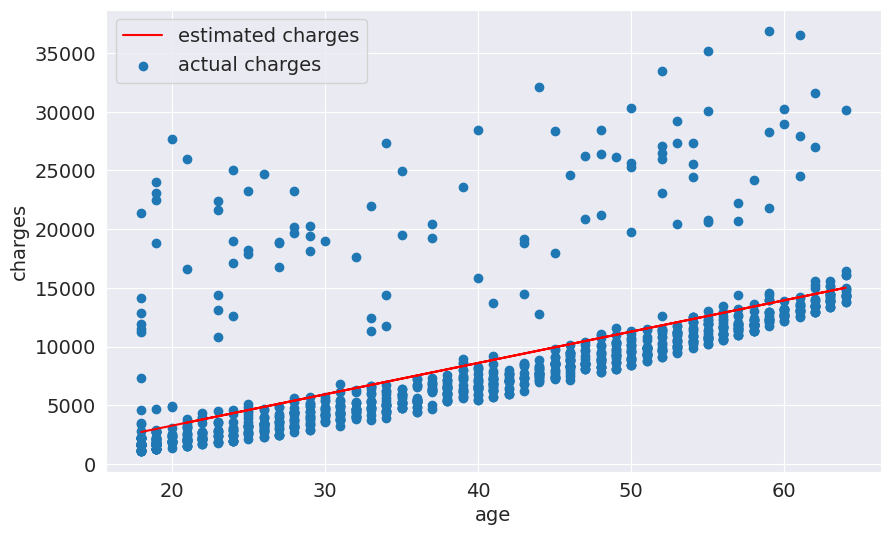

In [40]:
try_parameters(model.coef_,model.intercept_)

In [52]:
inputs, targets=non_smoker_df[['age','bmi','children']],non_smoker_df['charges']
model=LinearRegression().fit(inputs,targets)
predictions=model.predict(inputs)
loss=rmse(targets,predictions)
print('Rmse loss: ',loss)

Rmse loss:  4608.470405038247


In [51]:
non_smoker_df.charges.corr(non_smoker_df.children)

0.13892870453542192

In [55]:
inputs, targets=medical_df[['age','bmi','children','smoker']],medical_df['charges']
model=LinearRegression().fit(inputs,targets)
predictions=model.predict(inputs)
loss=rmse(targets,predictions)
print('Rmse loss: ',loss)

Rmse loss:  6056.439217188081


In [58]:
px.scatter(medical_df,x='age',y='charges',color="smoker",)

<Axes: xlabel='smoker', ylabel='charges'>

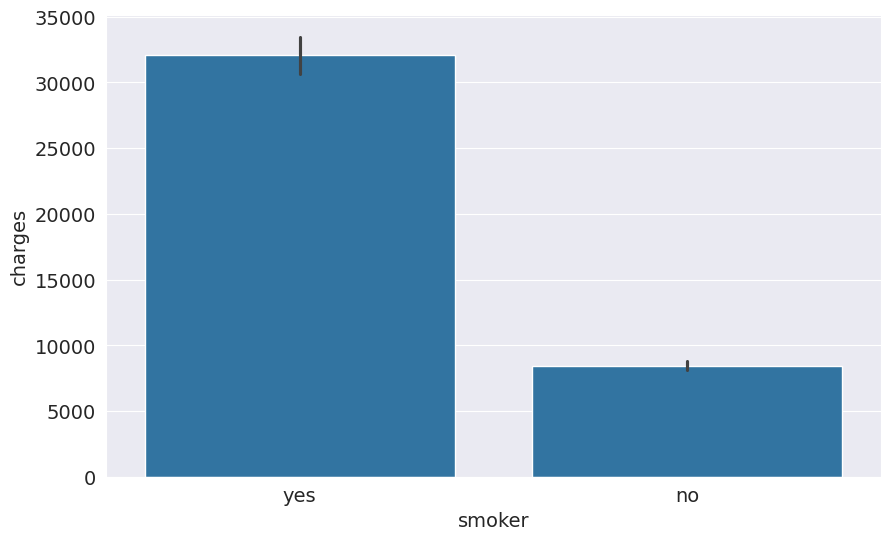

In [60]:
sns.barplot(medical_df,x='smoker',y='charges')

In [61]:
smoker_codes={'no':0,'yes':1}
medical_df['smoker_codes']=medical_df.smoker.map(smoker_codes)

In [70]:
inputs, targets=medical_df[['age','bmi','children','smoker_codes']],medical_df['charges']
model=LinearRegression().fit(inputs,targets)
predictions=model.predict(inputs)
loss=rmse(targets,predictions)
print('Rmse loss: ',loss)

Rmse loss:  6056.439217188081


In [71]:
from sklearn import preprocessing
enc=preprocessing.OneHotEncoder()
enc.fit(medical_df[['region']])
enc.categories_

[array(['northeast', 'northwest', 'southeast', 'southwest'], dtype=object)]

In [80]:
one_hot=enc.transform(medical_df[['region']]).toarray()
one_hot

array([[0., 0., 0., 1.],
       [0., 0., 1., 0.],
       [0., 0., 1., 0.],
       ...,
       [0., 0., 1., 0.],
       [0., 0., 0., 1.],
       [0., 1., 0., 0.]])

In [82]:
medical_df[['northeast','northwest','southeast','southwest']]=one_hot

In [94]:
inputs,targets=medical_df.drop(['region','sex','smoker','charges'],axis=1),medical_df.charges
model=LinearRegression().fit(inputs,targets)
predictions=model.predict(inputs)
loss=rmse(targets,predictions)
print('Rmse loss: ',loss)

Rmse loss:  6042.033215394104


In [95]:
model.predict([[28,30,2,1,0,0,1,0,0]])

/home/somanathan/Desktop/qgreeks-be-platform-apis/.venv/lib/python3.11/site-packages/sklearn/base.py:493: UserWarning:

X does not have valid feature names, but LinearRegression was fitted with feature names



array([29798.18088721])

In [98]:
from sklearn.preprocessing import StandardScaler
numeric_cols=['age','bmi','children']
scaler=StandardScaler()
scaler.fit(medical_df[numeric_cols])


StandardScaler()

In [101]:
print(scaler.mean_)
print(scaler.var_)

[39.20702541 30.66339686  1.09491779]
[197.25385199  37.16008997   1.45212664]


In [104]:
medical_df[numeric_cols]

,age,bmi,children
0,19,27.900,0
1,18,33.770,1
2,28,33.000,3
3,33,22.705,0
4,32,28.880,0
...,...,...,...
1333,50,30.970,3
1334,18,31.920,0
1335,18,36.850,0
1336,21,25.800,0


In [103]:
scaled_inputs=scaler.transform(medical_df[numeric_cols])
scaled_inputs

array([[-1.43876426, -0.45332   , -0.90861367],
       [-1.50996545,  0.5096211 , -0.07876719],
       [-0.79795355,  0.38330685,  1.58092576],
       ...,
       [-1.50996545,  1.0148781 , -0.90861367],
       [-1.29636188, -0.79781341, -0.90861367],
       [ 1.55168573, -0.26138796, -0.90861367]])

In [106]:
cat_cols=['smoker_codes','sex_codes','northeast','northwest','southeast','southwest']
categorical_data=medical_df[cat_cols].values

In [110]:
inputs=np.concatenate((scaled_inputs,categorical_data),axis=1)
targets=medical_df.charges
model=LinearRegression().fit(inputs, targets)
predictions=model.predict(inputs)
loss=rmse(targets,predictions)
print('Rmse loss: ',loss)

Rmse loss:  6042.35516199566


In [111]:
weights_df = pd.DataFrame({
    'feature': np.append(numeric_cols + cat_cols, 1),
    'weight': np.append(model.coef_, model.intercept_)
})
weights_df.sort_values('weight', ascending=False)

,feature,weight
5,northeast,1.047850e+17
6,northwest,1.047850e+17
7,southeast,1.047850e+17
8,southwest,1.047850e+17
3,smoker_codes,2.382355e+04
0,age,3.601075e+03
1,bmi,2.071174e+03
2,children,5.831904e+02
4,sex_codes,-1.021156e+12
9,1,-1.047850e+17


In [ ]:
from sklearn.model_selection import train_test_split
inputs_train, inputs_test, targets_train, targets_test = train_test_split(inputs, targets, test_size=0.1)

In [117]:
# Create and train the model
model = LinearRegression().fit(inputs_train, targets_train)

# Generate predictions
predictions_test = model.predict(inputs_test)

# Compute loss to evalute the model
loss = rmse(targets_test, predictions_test)
print('Test Loss:', loss)
# Generate predictions

Test Loss: 5860.062008814709


In [118]:
predictions_train = model.predict(inputs_train)

# Compute loss to evalute the model
loss = rmse(targets_train, predictions_train)
print('Training Loss:', loss)

Training Loss: 6063.990924603978
